---
# Sistemas Lineares

## Primeiro Exercício Computacional
---

Para os circuitos apresentados em sala:

**1)** Obtenha o modelo matemático entrada/saída.

**2)** Utilizando f(t)=sen(t), simule os modelos obtidos e plote $y \times t$ e $f \times t$ em um mesmo gráfico para cada circuito.

**3)** Refaça, modificando a entrada para:

$$ f(t) = \left\{
\begin{array}{ll}
0, & \text{para } t < 4\,\text{s} \\
1, & \text{para } t \geq 4\,\text{s}
\end{array}
\right. $$


## Obtenção das equações matemáticos

- Para o circuito RL:
$$\frac{dy(t)}{dt} + 3 y(t) = f(t)$$

- Para o circuito RC:
$$\frac{dy(t)}{dt} + 5y(t) = \frac{df}{dt}(t)$$


---
# Rotina computacional para resolução dos problemas
---

### Definindo Modelos, Parâmetros e Entradas

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Modelos genéricos para RL e RC
def modelo_RL(y, t, f): return -3*y + f(t)
def modelo_RC(y, t, dfdt): return dfdt(t) - 5*y 

# Entradas
f_sin = lambda t: np.sin(t) # Entrada senoidal
df_sin = lambda t: np.cos(t) # Derivada da entrada senoidal
f_step = lambda t: 1 if t >= 4 else 0 # Degrau 

epsilon = 1 # Aproximação de um impulso por um pulso. Epsilon define a largura e altura do pulso, de área sempre unitária
f_delta = lambda t: 1/epsilon if abs(t - 4) < epsilon/2 else 0 # Aproximação de Impulso Deslocado (derivada do degrau)

# Tempo e condições iniciais
t = np.linspace(0, 10, 10000)
y0 = 0

---
## Circuito RL
---

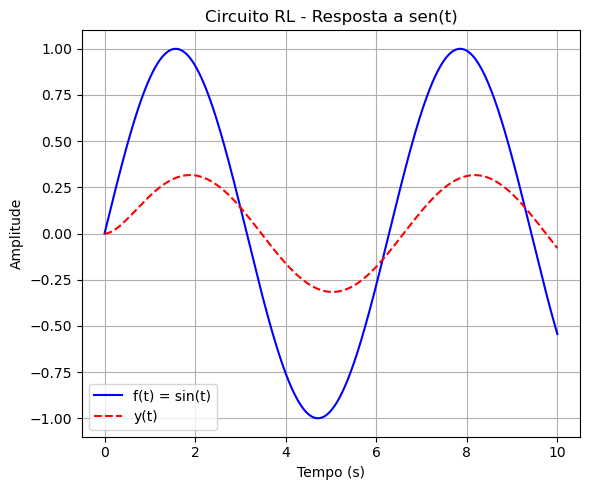

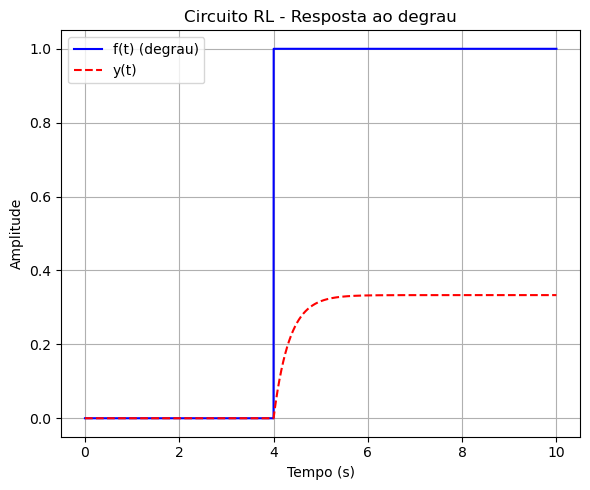

In [2]:
# Solução com entrada senoidal
y1 = odeint(modelo_RL, y0, t, args=(f_sin,))

# Plot da resposta senoidal
plt.figure(figsize=(6, 5))
plt.plot(t, np.sin(t), 'b-', label='f(t) = sin(t)')
plt.plot(t, y1, 'r--', label='y(t)')
plt.title('Circuito RL - Resposta a sen(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Solução com entrada degrau
y1_step = odeint(modelo_RL, y0, t, args=(f_step,))

# Plot da resposta ao degrau
f_step = np.array([f_step(ti) for ti in t])  # Resposta do degrau
plt.figure(figsize=(6, 5))
plt.plot(t, f_step, 'b-', label='f(t) (degrau)')
plt.plot(t, y1_step, 'r--', label='y(t)')
plt.title('Circuito RL - Resposta ao degrau')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

---
## Circuito RC
---

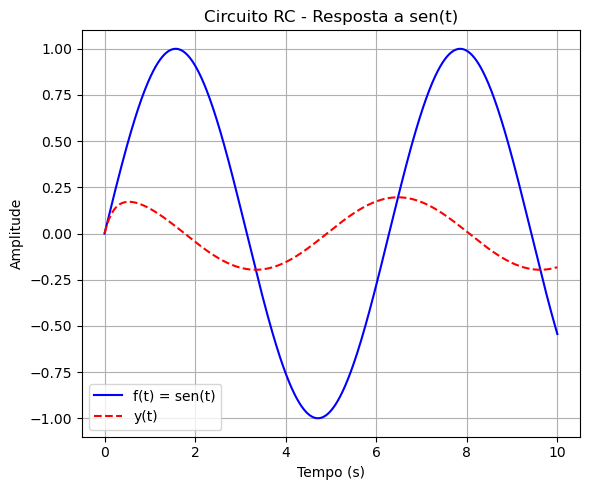

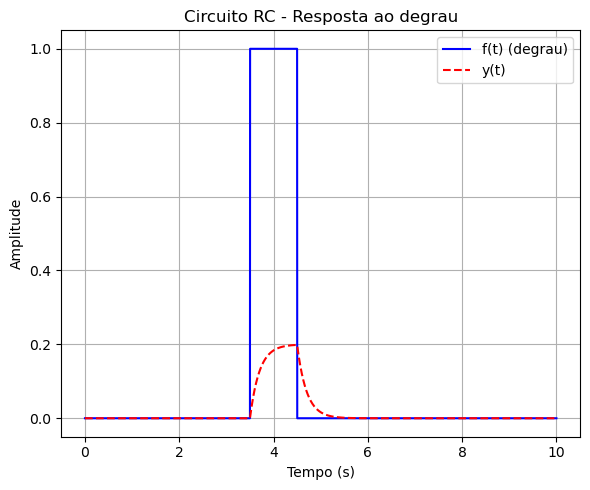

In [6]:
# Soluções com entrada senoidal
y2 = odeint(modelo_RC, y0, t, args=(df_sin,))

# Plot da resposta senoidal
plt.figure(figsize=(6, 5))
plt.plot(t, np.sin(t), 'b-', label='f(t) = sen(t)')
plt.plot(t, y2, 'r--', label='y(t)')
plt.title('Circuito RC - Resposta a sen(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Soluções com entrada degrau (aproximada por impulso deslocado)
y2_step = odeint(modelo_RC, y0, t, args=(f_delta,))  # Usando f_delta como derivada do degrau

# Plot da resposta ao degrau
f_delta = np.array([f_delta(ti) for ti in t])  # Resposta do degrau
plt.figure(figsize=(6, 5))
plt.plot(t, f_delta, 'b-', label='f(t) (degrau)')
plt.plot(t, y2_step, 'r--', label='y(t)')
plt.title('Circuito RC - Resposta ao degrau')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()